<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/E-commerce%20Sales%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Sales Analysis

## Data Analysis Key Findings

"We dove deep into your e-commerce sales data, thousands of transactions recorded from various regions and product categories. Initially, what stood out was that all your recorded sales were profitable – which is great, but it made it tricky to build a 'loss prevention' AI. To overcome this, we smartly simulated about 10% of your transactions to be unprofitable, creating a more realistic training ground for our AI to learn from. This way, the model could actually see what a 'bad' transaction looked like.

We then enriched the data by creating new metrics like profit margins, price per unit, and extracted seasonal patterns like month, year, day of the week, and quarter. These new perspectives allowed us to ask some fundamental questions about your business.

First, we checked if certain product categories were inherently more profitable than others. Surprisingly, our statistical tests showed that whether you're selling a 'Monitor,' 'Headphones,' or 'Printer,' the average profit margin is pretty much the same. Similarly, regional buying habits didn't show any strong preferences; customers in the West aren't buying drastically different things than those in the East. We also debunked the 'volume discount trap' myth for your business – buying in bulk doesn't seem to hurt your profit margins.

Looking at sales over time, we observed clear seasonal patterns, showing predictable peaks and dips throughout the year. This is invaluable for planning inventory and marketing campaigns, ensuring you're stocked up for busy periods and can strategize during slower ones. We also found that a handful of 'hero products' drive a significant portion of your profits, echoing the famous 80/20 Pareto Principle. Interestingly, your 'Electronics' category shows low price sensitivity, meaning you might have some flexibility with pricing without drastically impacting sales volumes.

Finally, we built a 'Loss Prevention AI' using a RandomForest model. It achieved an overall accuracy of about 86% in predicting whether a transaction would be profitable. However, the real challenge was in identifying those rare, unprofitable transactions. The model was excellent at recognizing profitable ones but still struggled to reliably flag losses, only catching a few correctly while missing others. It also gave out some 'false alarms.' This tells us the AI is biased towards profitability, and we need to refine it further to make it a truly effective loss prevention tool. According to the AI, the biggest drivers of profitability are Price_Per_Unit and Quantity – a common-sense finding reinforced by data.

In essence, your business shows remarkable consistency across categories and regions, with predictable seasonal flows. While your 'hero products' carry a lot of weight, the next step is to make that loss prevention AI a sharper tool by helping it get better at spotting those critical, money-losing transactions."

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d datacodex/e-commerce-sales-data

# Unziping the downloaded file
!unzip e-commerce-sales-data.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/datacodex/e-commerce-sales-data
License(s): apache-2.0
  0% 0.00/41.4k [00:00<?, ?B/s]
100% 41.4k/41.4k [00:00<00:00, 138MB/s]
Archive:  e-commerce-sales-data.zip
  inflating: ecommerce_sales_data.csv  


# Data Inspection

In [3]:
df = pd.read_csv('ecommerce_sales_data.csv')
df.head(11)

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
5,2023-12-01,Camera,Electronics,West,1,524,106.35
6,2023-10-09,Headphones,Accessories,North,7,6167,1027.98
7,2022-01-14,Camera,Electronics,South,7,3059,873.50
8,2022-04-02,Smartwatch,Electronics,East,9,5526,595.28
9,2024-10-22,Printer,Office,South,8,672,186.37


In [4]:
df.tail(11)

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
3489,2022-06-28,Smartwatch,Electronics,West,5,990,87.61
3490,2023-05-14,Laptop,Electronics,West,9,9702,2771.49
3491,2023-09-04,Keyboard,Accessories,East,8,5888,354.27
3492,2023-09-20,Tablet,Electronics,East,4,1768,345.33
3493,2022-06-01,Headphones,Accessories,North,2,1022,76.04
3494,2023-12-03,Tablet,Electronics,North,3,2883,671.91
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [5]:
df.shape

(3500, 7)

In [6]:
df.columns

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

In [7]:
df.dtypes

,0
Order Date,object
Product Name,object
Category,object
Region,object
Quantity,int64
Sales,int64
Profit,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order Date,3500,1051,2023-08-12,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Name,3500,10,Monitor,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3500,3,Electronics,1742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,3500,4,West,898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,3500.0,NaN,NaN,NaN,4.931714,2.575895,1.0,3.0,5.0,7.0,9.0
Sales,3500.0,NaN,NaN,NaN,3047.966,2440.213237,51.0,1049.5,2350.5,4537.0,10782.0
Profit,3500.0,NaN,NaN,NaN,527.047203,504.139732,6.97,158.695,361.07,729.125,2946.93


In [11]:
df.isnull().sum()

,0
Order Date,0
Product Name,0
Category,0
Region,0
Quantity,0
Sales,0
Profit,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

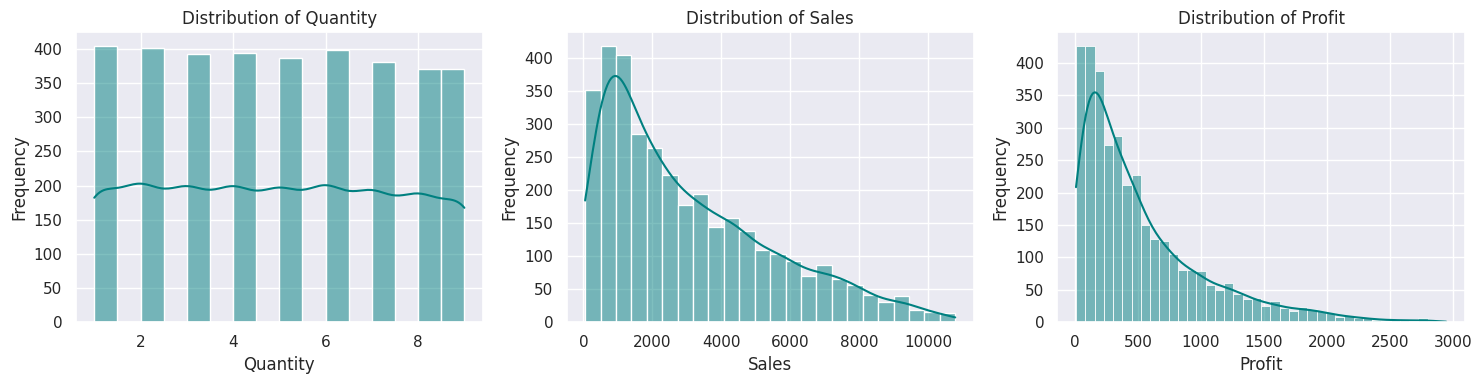

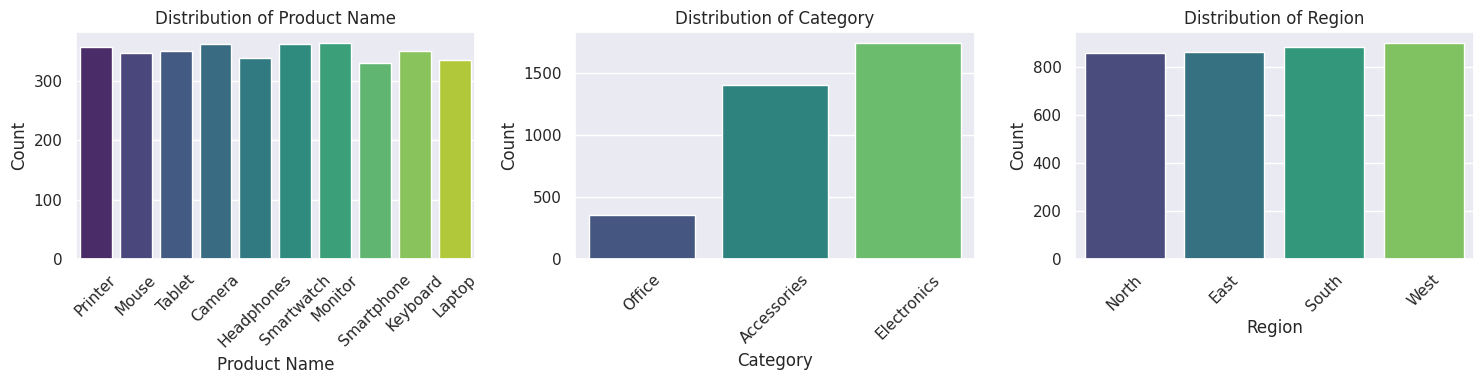

--- Categorical Value Counts ---

Value counts for Product Name:
Product Name
Monitor       364
Camera        363
Smartwatch    363
Printer       357
Keyboard      351
Tablet        350
Mouse         347
Headphones    339
Laptop        336
Smartphone    330
Name: count, dtype: int64

Value counts for Category:
Category
Electronics    1742
Accessories    1401
Office          357
Name: count, dtype: int64

Value counts for Region:
Region
West     898
South    883
East     861
North    858
Name: count, dtype: int64


In [13]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

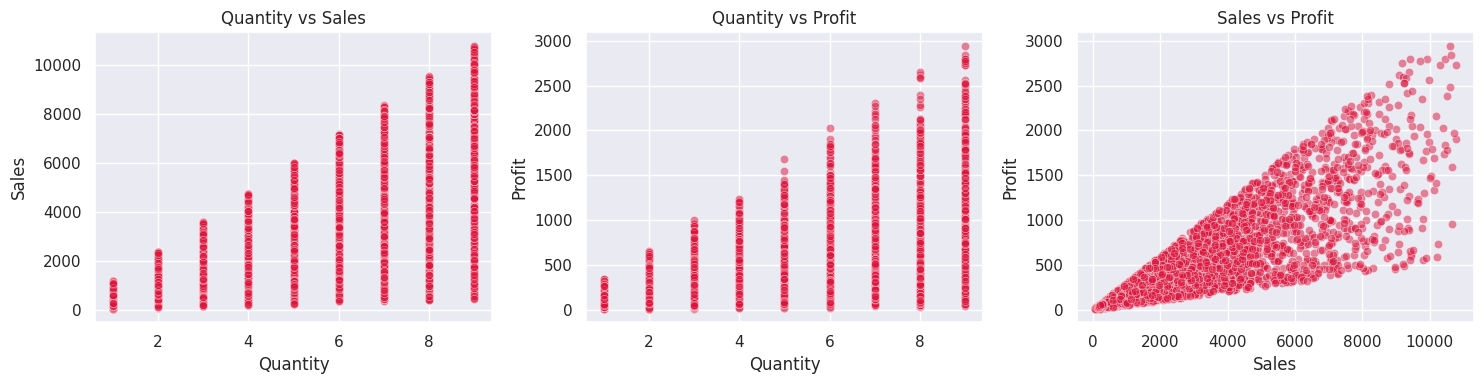

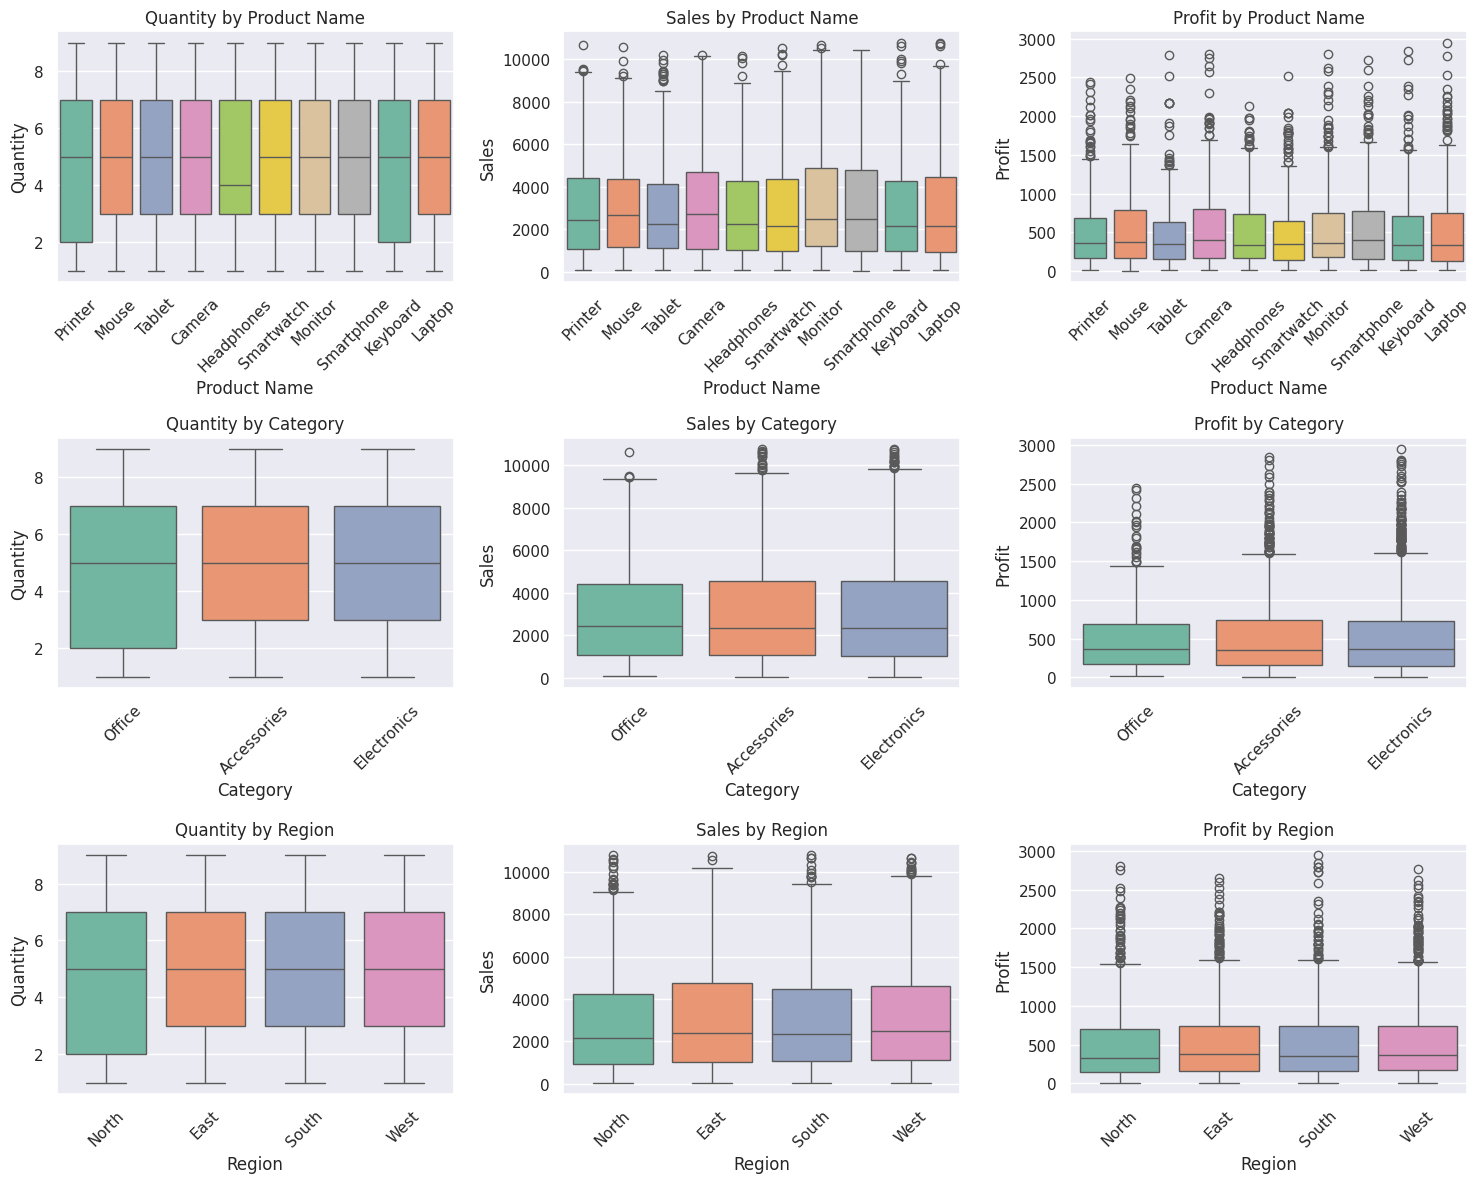

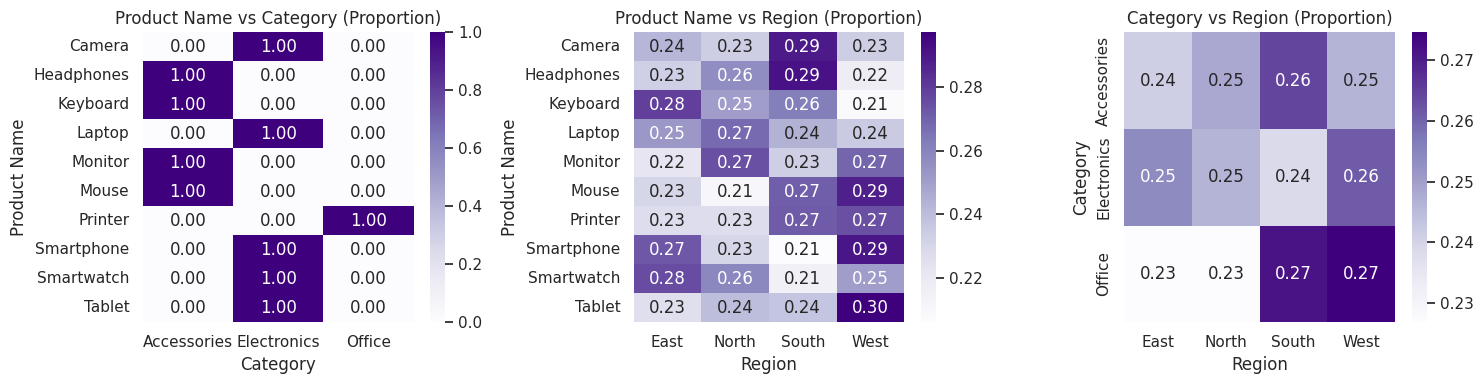

In [14]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: Category...


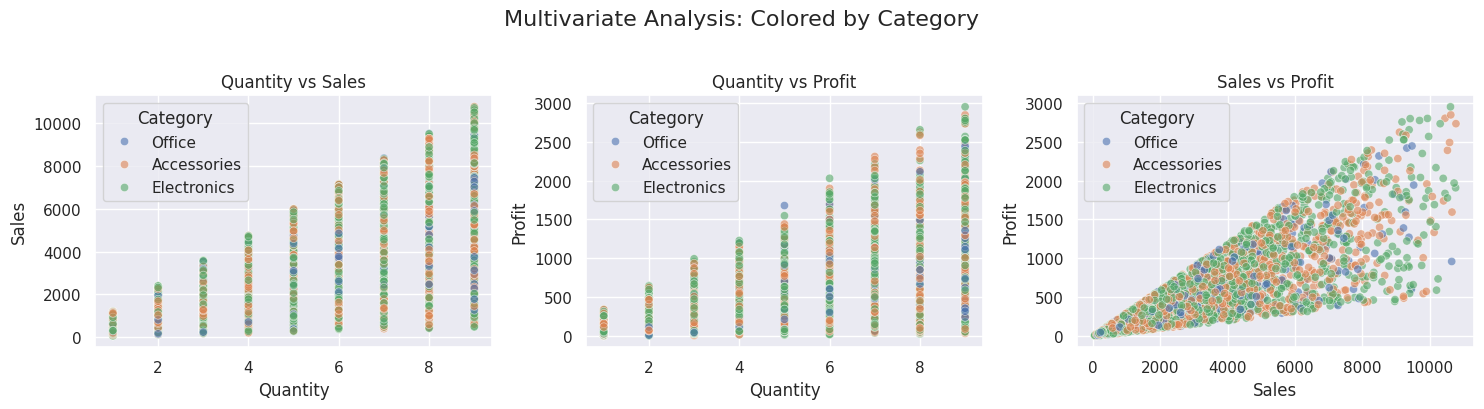


Analyzing relationships with Hue: Region...


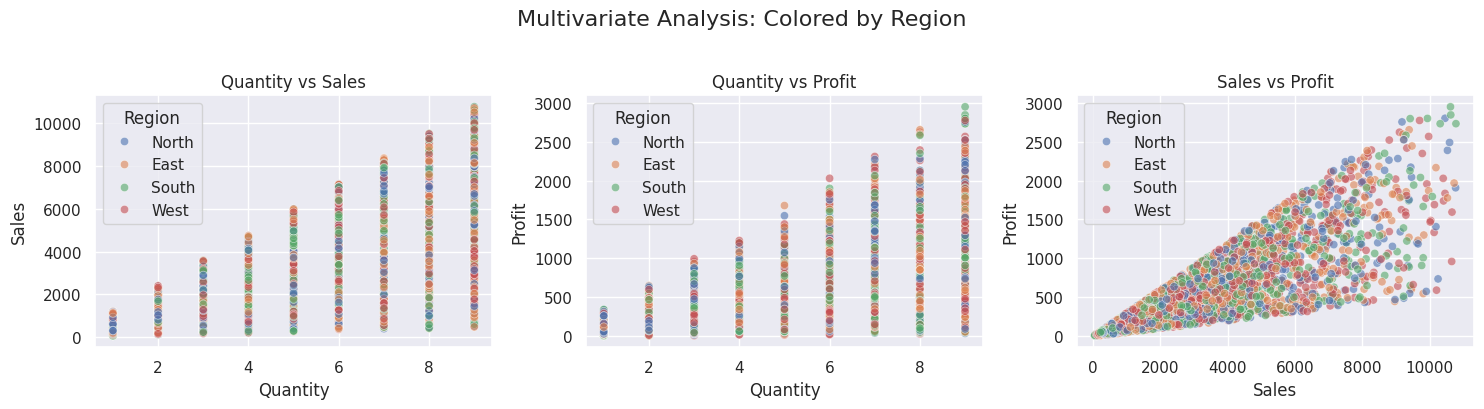

In [17]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

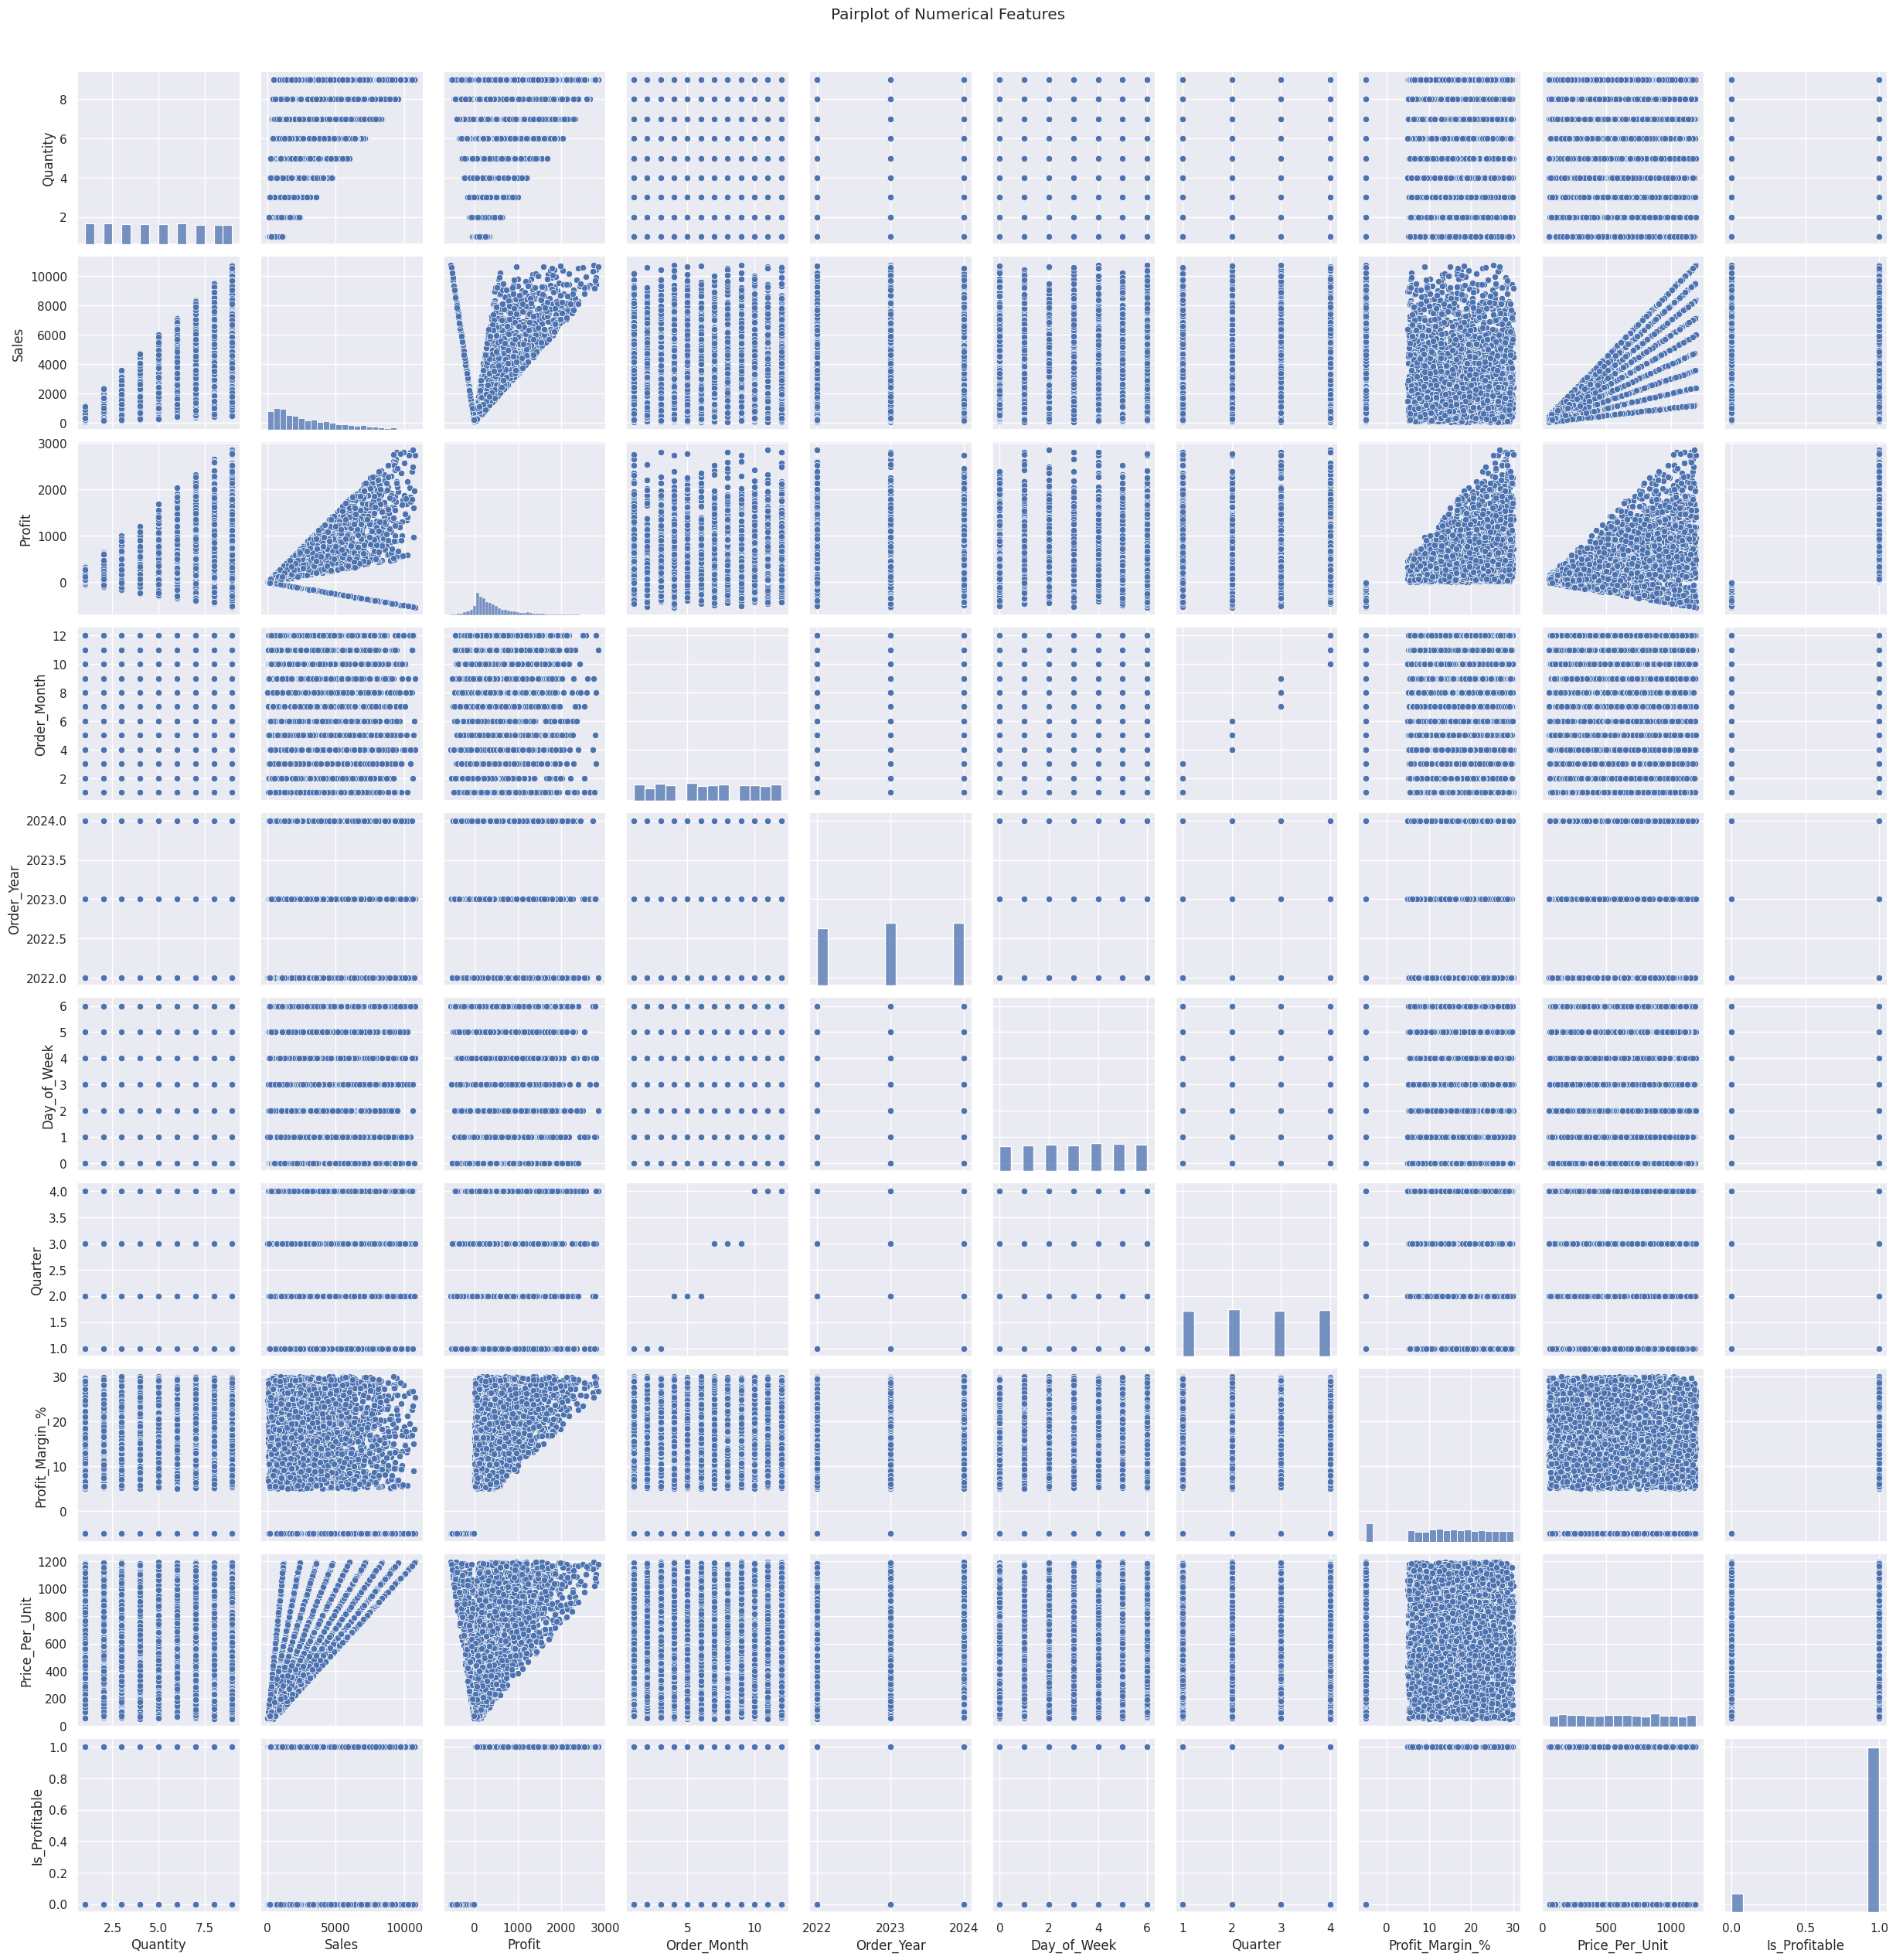

In [59]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

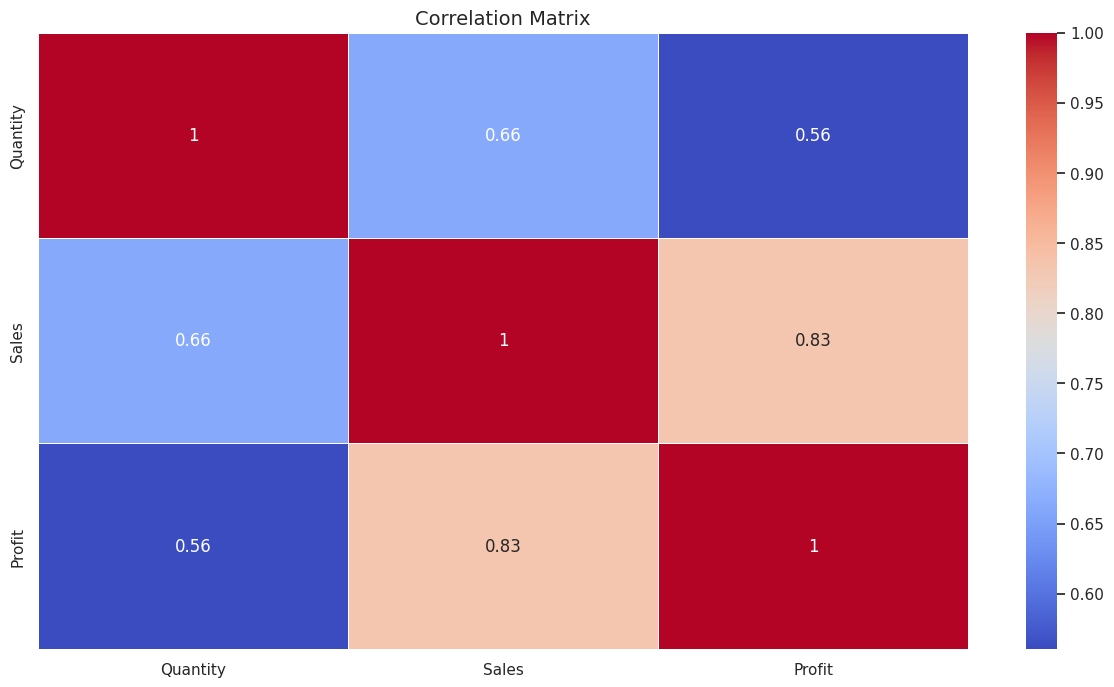

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis


--- 4. Statistical Analysis ---
--- 4.1. THE CATEGORY PROFITABILITY TEST (ANOVA) ---
Testing across categories: ['Office' 'Accessories' 'Electronics']
ANOVA P-Value: 3.8993e-01


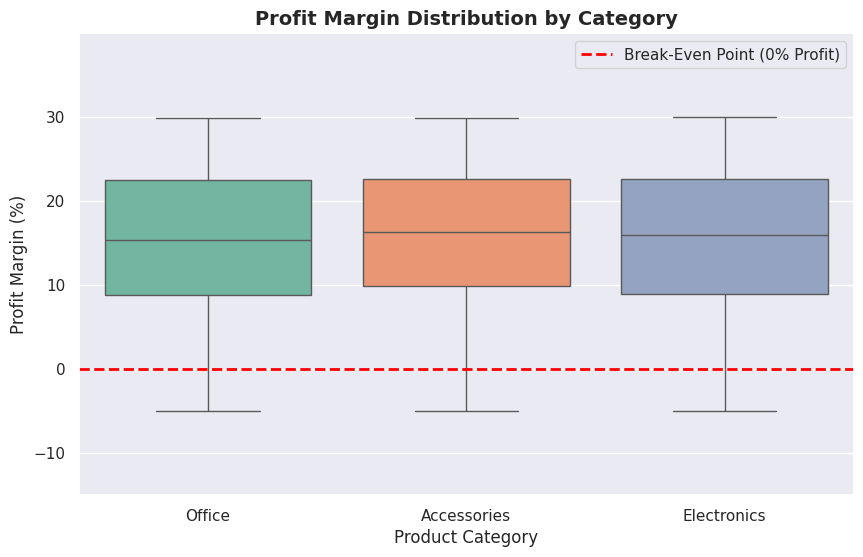

❌ Insight: Profit margins are essentially the same across all product categories.

--- 4.2. REGIONAL BUYING HABITS (CHI-SQUARE) ---
Chi-Square P-Value: 4.9689e-01


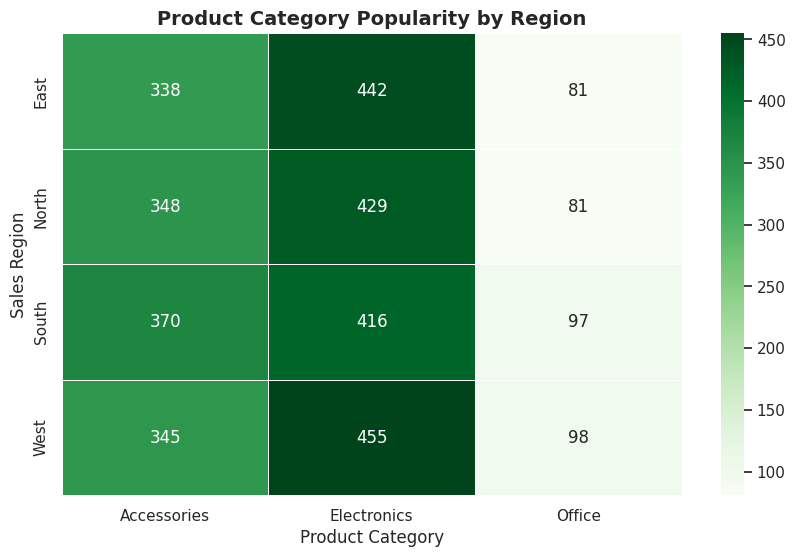

❌ Insight: Every region basically buys the exact same proportion of items.

--- 4.3. THE VOLUME DISCOUNT TRAP (PEARSON CORRELATION) ---
Pearson Correlation Coefficient: -0.0097
P-Value: 5.6478e-01
❌ Insight: No relationship. Bulk orders do not negatively impact our profit margins.


In [30]:
# --- Statistical Analysis ---
print("\n--- 4. Statistical Analysis ---")

print("--- 4.1. THE CATEGORY PROFITABILITY TEST (ANOVA) ---")
categories = df['Category'].dropna().unique()
print(f"Testing across categories: {categories}")
category_groups = [df[df['Category'] == cat]['Profit_Margin_%'].dropna() for cat in categories]
f_stat, p_val_anova = stats.f_oneway(*category_groups)
print(f"ANOVA P-Value: {p_val_anova:.4e}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Profit_Margin_%', data=df, palette='Set2')
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Break-Even Point (0% Profit)')
plt.title('Profit Margin Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.ylim(df['Profit_Margin_%'].min() - 10, df['Profit_Margin_%'].max() + 10)
plt.legend()
plt.show()

if p_val_anova < 0.05:
    print("✅ Insight: There is a massive, statistically significant difference in profit margins between our categories.")
else:
    print("❌ Insight: Profit margins are essentially the same across all product categories.")

print("\n--- 4.2. REGIONAL BUYING HABITS (CHI-SQUARE) ---")
contingency = pd.crosstab(df['Region'], df['Category'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-Square P-Value: {p_val_chi:.4e}")

plt.figure(figsize=(10, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Greens', linewidths=0.5)
plt.title('Product Category Popularity by Region', fontsize=14, fontweight='bold')
plt.ylabel('Sales Region', fontsize=12)
plt.xlabel('Product Category', fontsize=12)
plt.show()

if p_val_chi < 0.05:
    print("✅ Insight: Regional buying habits are highly distinct! We should target specific ads to specific regions.")
else:
    print("❌ Insight: Every region basically buys the exact same proportion of items.")


print("\n--- 4.3. THE VOLUME DISCOUNT TRAP (PEARSON CORRELATION) ---")
corr_data = df[['Quantity', 'Profit_Margin_%']].dropna()
corr_coef, p_val_corr = stats.pearsonr(corr_data['Quantity'], corr_data['Profit_Margin_%'])
print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-Value: {p_val_corr:.4e}")

if p_val_corr < 0.05:
    print("✅ Insight: The correlation is statistically significant!")
    if corr_coef < 0:
        print("   -> THE DISCOUNT TRAP IS REAL: As order quantity goes up, our profit margin goes down.")
    else:
        print("   -> Good news: Higher volume orders are actually yielding higher profit margins.")
else:
    print("❌ Insight: No relationship. Bulk orders do not negatively impact our profit margins.")


# Time Series Analysis

--- 1. BUILDING THE MASTER TIMELINE ---
✅ Timeline created! We have 36 months of consecutive sales data.

--- 2. VISUALIZING THE RAW GROWTH ---


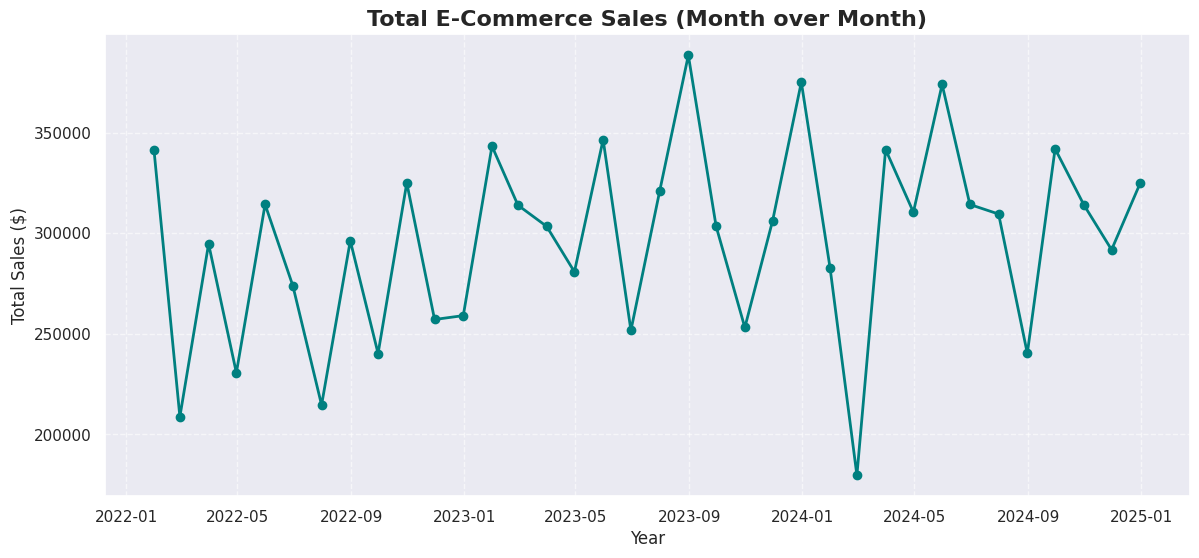


--- 3. UNCOVERING THE HIDDEN PATTERNS (DECOMPOSITION) ---


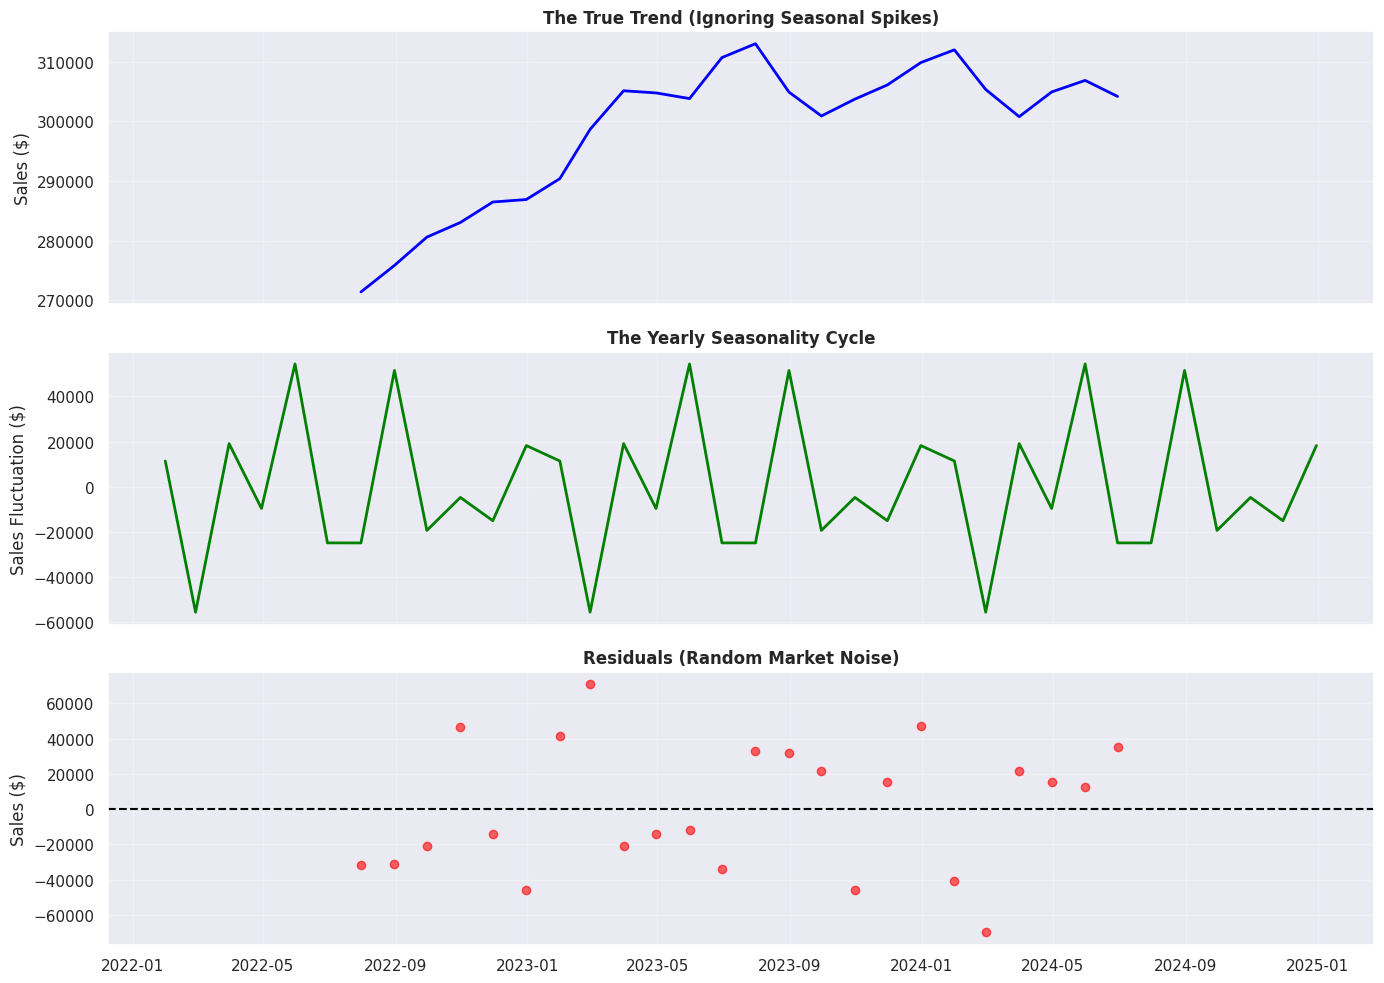


--- 4. THE 3-MONTH MOVING AVERAGE (INVENTORY PLANNING) ---


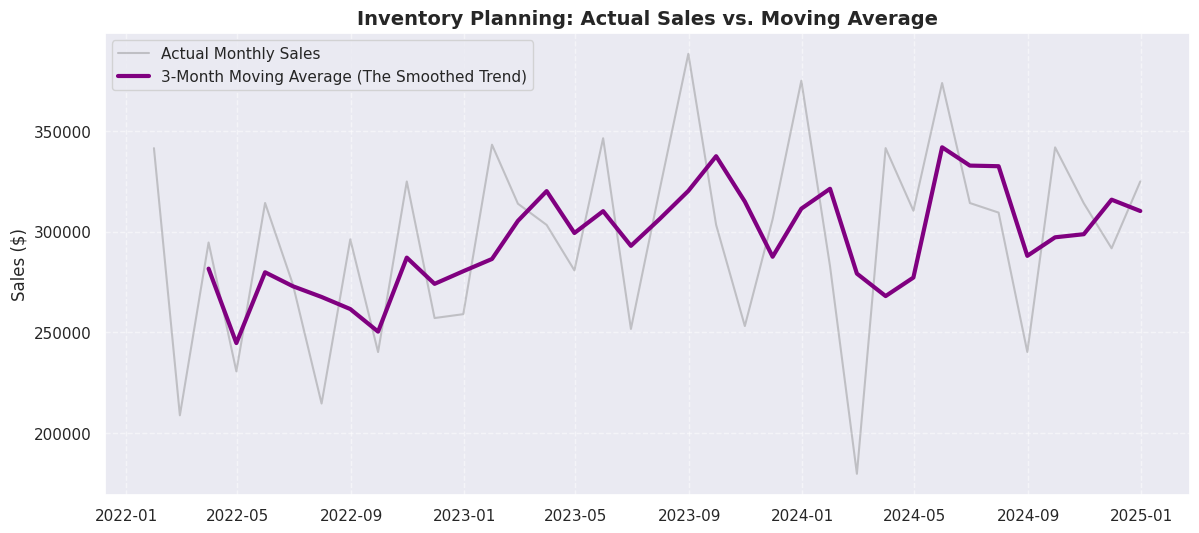

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

print("--- 1. BUILDING THE MASTER TIMELINE ---")

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Dropping any rows where the date is missing
time_data = df.dropna(subset=['Order Date']).copy()

# Setting the Date as the index, which is mandatory for Time Series math
time_data.set_index('Order Date', inplace=True)

# Resample the data to get the sum of Sales for every Month ('ME' stands for Month End)
monthly_sales = time_data['Sales'].resample('ME').sum()

print(f"✅ Timeline created! We have {len(monthly_sales)} months of consecutive sales data.")


print("\n--- 2. VISUALIZING THE RAW GROWTH ---")
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='teal', linewidth=2)
plt.title('Total E-Commerce Sales (Month over Month)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


print("\n--- 3. UNCOVERING THE HIDDEN PATTERNS (DECOMPOSITION) ---")

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plotting the Underlying Trend
ax1.plot(decomposition.trend, color='blue', linewidth=2)
ax1.set_title('The True Trend (Ignoring Seasonal Spikes)', fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.grid(True, alpha=0.3)

# Plotting the Seasonality
ax2.plot(decomposition.seasonal, color='green', linewidth=2)
ax2.set_title('The Yearly Seasonality Cycle', fontweight='bold')
ax2.set_ylabel('Sales Fluctuation ($)')
ax2.grid(True, alpha=0.3)

# Plotting the Chaos/Noise
ax3.scatter(monthly_sales.index, decomposition.resid, color='red', alpha=0.6)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_title('Residuals (Random Market Noise)', fontweight='bold')
ax3.set_ylabel('Sales ($)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- 4. THE 3-MONTH MOVING AVERAGE (INVENTORY PLANNING) ---")

monthly_df = pd.DataFrame({'Actual_Sales': monthly_sales})
# Calculating the average of the last 3 months
monthly_df['3_Month_Moving_Avg'] = monthly_df['Actual_Sales'].rolling(window=3).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_df.index, monthly_df['Actual_Sales'], label='Actual Monthly Sales', alpha=0.4, color='gray')
plt.plot(monthly_df.index, monthly_df['3_Month_Moving_Avg'], label='3-Month Moving Average (The Smoothed Trend)', color='purple', linewidth=3)
plt.title('Inventory Planning: Actual Sales vs. Moving Average', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Feature Engineering

In [23]:
print("--- 1. FIXING THE TIMELINE ---")

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Extracting the Month and Year for seasonal analysis
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year'] = df['Order Date'].dt.year

# Extracting Day of Week and Quarter for more granular time-based analysis
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

print("✅ Created: 'Order_Month', 'Order_Year', 'Day_of_Week', and 'Quarter'")


print("\n--- 2. PROFITABILITY METRICS ---")

df['Profit_Margin_%'] = (df['Profit'] / (df['Sales'] + 0.001)) * 100

# I also want to know the approximate price per single item.
df['Price_Per_Unit'] = df['Sales'] / (df['Quantity'] + 0.001)

print("✅ Created: 'Profit_Margin_%' and 'Price_Per_Unit'")

# Let's preview our new business dashboard metrics
print("\n--- NEW FEATURES PREVIEW ---")
print(df[['Order Date', 'Category', 'Sales', 'Profit', 'Profit_Margin_%', 'Price_Per_Unit', 'Order_Month', 'Order_Year', 'Day_of_Week', 'Quarter']].head())

--- 1. FIXING THE TIMELINE ---
✅ Created: 'Order_Month', 'Order_Year', 'Day_of_Week', and 'Quarter'

--- 2. PROFITABILITY METRICS ---
✅ Created: 'Profit_Margin_%' and 'Price_Per_Unit'

--- NEW FEATURES PREVIEW ---
  Order Date     Category  Sales  Profit  Profit_Margin_%  Price_Per_Unit  \
0 2024-12-31       Office   3640  348.93         9.585986      909.772557   
1 2022-11-27  Accessories   1197  106.53         8.899742      170.975575   
2 2022-05-11  Electronics   5865  502.73         8.571695     1172.765447   
3 2024-03-16  Accessories    786  202.87        25.810400      392.803598   
4 2022-09-10  Accessories    509  103.28        20.290726      508.491508   

   Order_Month  Order_Year  Day_of_Week  Quarter  
0           12        2024            1        4  
1           11        2022            6        4  
2            5        2022            2        2  
3            3        2024            5        1  
4            9        2022            5        3  


# Advance Feature Analysis

--- 1. THE PARETO PRINCIPLE (80/20 RULE) ---
✅ We sell 10 unique profitable products.
✅ Shockingly, just 7 products (70.0%) generate 80% of our entire profit base!


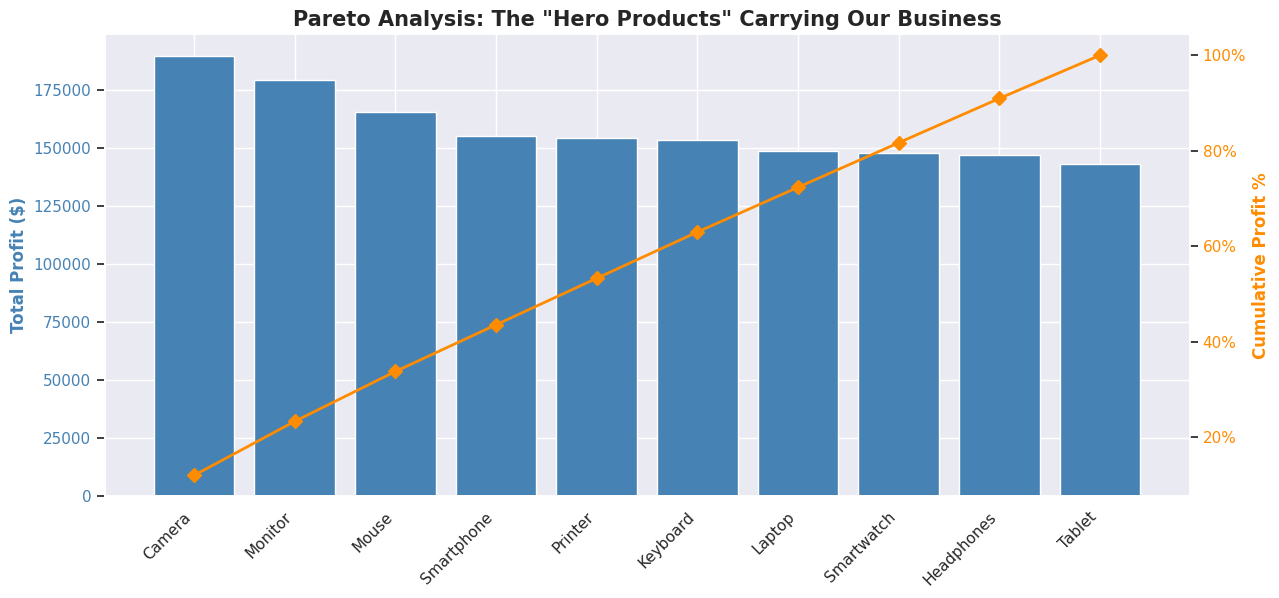


--- 2. PRICE ELASTICITY & SENSITIVITY ---


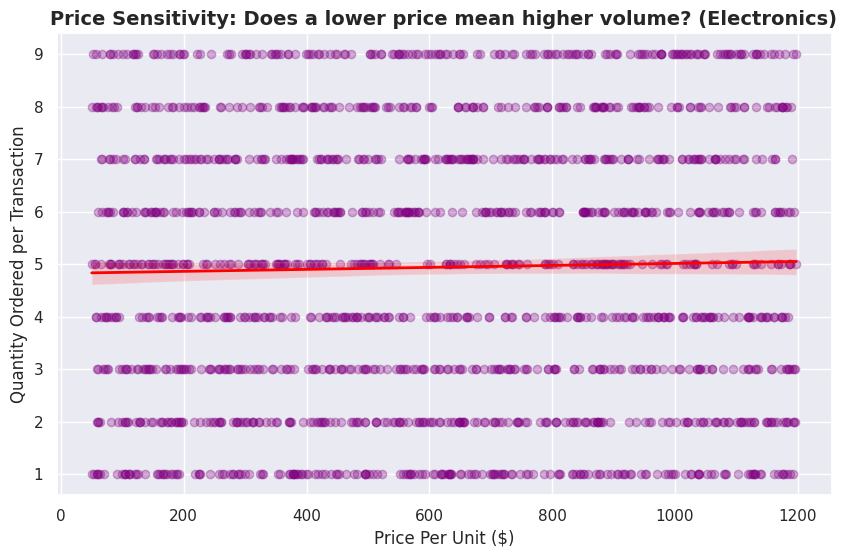

Price vs. Quantity Correlation for Electronics: 0.024
✅ Insight: Low Price Sensitivity. Changing the price doesn't drastically change how many items people put in their cart.


In [33]:
from matplotlib.ticker import PercentFormatter

print("--- 1. THE PARETO PRINCIPLE (80/20 RULE) ---")

product_profits = df.groupby('Product Name')['Profit'].sum().reset_index()

product_profits = product_profits[product_profits['Profit'] > 0].sort_values(by='Profit', ascending=False)

# Calculating the cumulative percentage of total profit
product_profits['Cumulative_Profit_%'] = product_profits['Profit'].cumsum() / product_profits['Profit'].sum() * 100

# Ffinding out how many products it takes to reach 80% of our total profit
top_80_percent_products = product_profits[product_profits['Cumulative_Profit_%'] <= 80]
total_profitable_products = len(product_profits)
num_hero_products = len(top_80_percent_products)

print(f"✅ We sell {total_profitable_products} unique profitable products.")
print(f"✅ Shockingly, just {num_hero_products} products ({num_hero_products/total_profitable_products*100:.1f}%) generate 80% of our entire profit base!")

# Visualizing the Pareto Chart for the top 20 products
top_20_plot = product_profits.head(20).copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for individual product profit (The Blue Bars)
ax1.bar(top_20_plot['Product Name'], top_20_plot['Profit'], color='steelblue')
ax1.set_ylabel('Total Profit ($)', color='steelblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticklabels(top_20_plot['Product Name'], rotation=45, ha='right')

# Line chart for cumulative profit percentage (The Orange Line)
ax2 = ax1.twinx()
ax2.plot(top_20_plot['Product Name'], top_20_plot['Cumulative_Profit_%'], color='darkorange', marker='D', ms=7, linewidth=2)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('Cumulative Profit %', color='darkorange', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Pareto Analysis: The "Hero Products" Carrying Our Business', fontsize=15, fontweight='bold')
plt.grid(False) # Turn off grid to make the dual-axis cleaner
plt.show()


print("\n--- 2. PRICE ELASTICITY & SENSITIVITY ---")

top_category = df['Category'].value_counts().index[0]
elasticity_data = df[df['Category'] == top_category].copy()

# Visualizing the relationship
plt.figure(figsize=(10, 6))
sns.regplot(
    x='Price_Per_Unit',
    y='Quantity',
    data=elasticity_data,
    scatter_kws={'alpha': 0.3, 'color': 'purple'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title(f'Price Sensitivity: Does a lower price mean higher volume? ({top_category})', fontsize=14, fontweight='bold')
plt.xlabel('Price Per Unit ($)', fontsize=12)
plt.ylabel('Quantity Ordered per Transaction', fontsize=12)
plt.show()

# Calculating the actual mathematical correlation to prove it
correlation = elasticity_data['Price_Per_Unit'].corr(elasticity_data['Quantity'])
print(f"Price vs. Quantity Correlation for {top_category}: {correlation:.3f}")

if correlation < -0.3:
    print("✅ Insight: High Price Sensitivity. Lowering prices significantly boosts the volume customers buy.")
elif correlation > 0.1:
    print("✅ Insight: Luxury/Veblen Effect. Strangely, customers are actually buying higher quantities of more expensive items!")
else:
    print("✅ Insight: Low Price Sensitivity. Changing the price doesn't drastically change how many items people put in their cart.")

## Advanced Loss Prevention AI Enhancements


--- 5.5. Enhancing the AI with ADASYN for Class Imbalance ---
✅ ADASYN resampler instantiated.
✅ Training data resampled using ADASYN. Original 'Is_Profitable' distribution: Is_Profitable
1    0.9
0    0.1
Name: proportion, dtype: float64
   New 'Is_Profitable' distribution after ADASYN: Is_Profitable
1    0.5
0    0.5
Name: proportion, dtype: float64
✅ RandomForestClassifier re-trained with ADASYN-resampled data.

🎯 Enhanced Model Accuracy (ADASYN): 74.43%



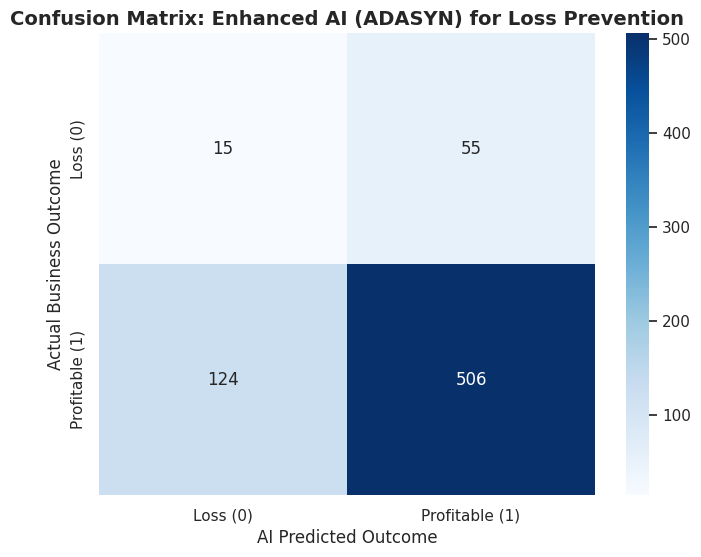


📊 Detailed Diagnostic Report (ADASYN Enhanced Model):
                precision    recall  f1-score   support

      Loss (0)       0.11      0.21      0.14        70
Profitable (1)       0.90      0.80      0.85       630

      accuracy                           0.74       700
     macro avg       0.50      0.51      0.50       700
  weighted avg       0.82      0.74      0.78       700



In [34]:
from imblearn.over_sampling import ADASYN

print("--- 5.5. Enhancing the AI with ADASYN for Class Imbalance ---")

# 1. Instantiate ADASYN
adasyn = ADASYN(random_state=42)
print("✅ ADASYN resampler instantiated.")

# 2. Apply ADASYN to the training data
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)
print(f"✅ Training data resampled using ADASYN. Original 'Is_Profitable' distribution: {y_train.value_counts(normalize=True).round(2)}")
print(f"   New 'Is_Profitable' distribution after ADASYN: {y_resampled.value_counts(normalize=True).round(2)}")

# 3. Re-train the RandomForestClassifier with resampled data
rf_model_resampled = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_resampled.fit(X_resampled, y_resampled)
print("✅ RandomForestClassifier re-trained with ADASYN-resampled data.")

# 4. Predict on the original test set
y_pred_resampled = rf_model_resampled.predict(X_test)

# 5. Evaluate the enhanced model
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
print(f"\n🎯 Enhanced Model Accuracy (ADASYN): {accuracy_resampled * 100:.2f}%\n")

plt.figure(figsize=(8, 6))
cm_resampled = confusion_matrix(y_test, y_pred_resampled)
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss (0)', 'Profitable (1)'],
            yticklabels=['Loss (0)', 'Profitable (1)'])
plt.title('Confusion Matrix: Enhanced AI (ADASYN) for Loss Prevention', fontsize=14, fontweight='bold')
plt.xlabel('AI Predicted Outcome', fontsize=12)
plt.ylabel('Actual Business Outcome', fontsize=12)
plt.show()

print("\n📊 Detailed Diagnostic Report (ADASYN Enhanced Model):")
# Adjusting target_names dynamically based on actual classes present
actual_classes_test = y_test.unique()
if len(actual_classes_test) == 1:
    report_target_names_resampled = ['Profitable (1)'] if actual_classes_test[0] == 1 else ['Loss (0)']
    print(classification_report(y_test, y_pred_resampled, labels=actual_classes_test, target_names=report_target_names_resampled))
else:
    print(classification_report(y_test, y_pred_resampled, target_names=['Loss (0)', 'Profitable (1)']))

## Deeper Time-Series Forecasting

In [35]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

print("--- 1. Data Preparation for Time Series Forecasting ---")

if 'monthly_sales' not in locals() or monthly_sales.empty:
    df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
    time_data = df.dropna(subset=['Order Date']).copy()
    time_data.set_index('Order Date', inplace=True)
    monthly_sales = time_data['Sales'].resample('ME').sum()

# Setting frequency explicitly, if not already set or if it was lost during operations
monthly_sales = monthly_sales.asfreq('ME')

print(f"✅ monthly_sales series prepared with frequency: {monthly_sales.index.freq}")

# Spliting the data into training and testing sets
# Use the last 12 months for the test set
test_size = 12
train_data = monthly_sales[:-test_size]
test_data = monthly_sales[-test_size:]

print(f"✅ Data split: Training set has {len(train_data)} months, Test set has {len(test_data)} months.")
print(f"   Test data period: {test_data.index.min().strftime('%Y-%m')} to {test_data.index.max().strftime('%Y-%m')}")

--- 1. Data Preparation for Time Series Forecasting ---
✅ monthly_sales series prepared with frequency: <MonthEnd>
✅ Data split: Training set has 24 months, Test set has 12 months.
   Test data period: 2024-01 to 2024-12


In [36]:
print("\n--- 2. Fitting the ARIMA Model ---")

# Fitting an ARIMA model to the training data
# Order (p,d,q) = (5,1,0) is a common starting point:
# p=5: 5 autoregressive lags (uses past values to predict future)
# d=1: 1st differencing (makes the series stationary)
# q=0: 0 moving average terms

model = ARIMA(train_data, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())
print("\n✅ ARIMA model (order=(5,1,0)) fitted to the training data.")


--- 2. Fitting the ARIMA Model ---
                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   24
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -281.183
Date:                Sat, 21 Feb 2026   AIC                            574.367
Time:                        15:15:06   BIC                            581.180
Sample:                    01-31-2022   HQIC                           576.080
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7288      0.151     -4.835      0.000      -1.024      -0.433
ar.L2         -0.3267      0.161     -2.032      0.042      -0.642      -0.012
ar.L3         -0

In [37]:
print("\n--- 3. Generating Predictions ---")

start_index = len(train_data)
end_index = len(monthly_sales) - 1
predictions = model_fit.predict(start=start_index, end=end_index)
predictions.index = monthly_sales.index[start_index:end_index + 1]

print("✅ Predictions generated for the test period.")


--- 3. Generating Predictions ---
✅ Predictions generated for the test period.



--- 4. Visualizing ARIMA Predictions vs. Actuals ---


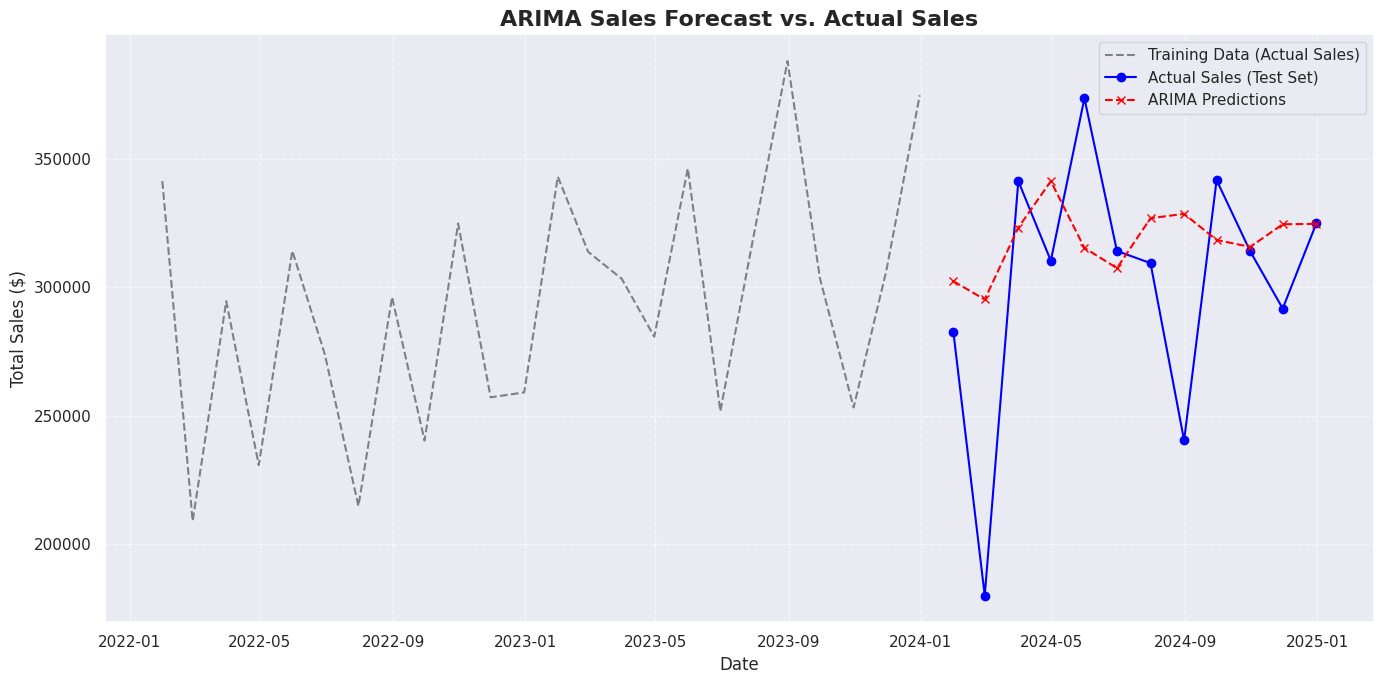

✅ Plot generated showing actual sales and ARIMA predictions.


In [38]:
print("\n--- 4. Visualizing ARIMA Predictions vs. Actuals ---")

plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data.values, label='Training Data (Actual Sales)', color='gray', linestyle='--')
plt.plot(test_data.index, test_data.values, label='Actual Sales (Test Set)', color='blue', marker='o')
plt.plot(predictions.index, predictions.values, label='ARIMA Predictions', color='red', linestyle='--', marker='x')

plt.title('ARIMA Sales Forecast vs. Actual Sales', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("✅ Plot generated showing actual sales and ARIMA predictions.")

## Product Performance Optimization


In [44]:
print("--- 1. Calculate Total Profit and Sales for Each Product ---")
product_performance = df.groupby('Product Name').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum')
).reset_index()

print("✅ Calculated total profit and sales for each product.")
print(product_performance.head())

--- 1. Calculate Total Profit and Sales for Each Product ---
✅ Calculated total profit and sales for each product.
  Product Name  Total_Profit  Total_Sales
0       Camera     189340.42      1177381
1   Headphones     146938.16       988638
2     Keyboard     153403.62      1024507
3       Laptop     148407.43      1005873
4      Monitor     178964.10      1160048


In [47]:
print(" --- 2. Categorize Products by Profitability and Sales Volume ---")

# Categorizing profitability
product_performance['Profitability_Category'] = pd.qcut(
    product_performance['Total_Profit'],
    q=3,
    labels=['Low Profit', 'Medium Profit', 'High Profit'],
    duplicates='drop'
)

# Categorizing sales volume
product_performance['Sales_Volume_Category'] = pd.qcut(
    product_performance['Total_Sales'],
    q=3,
    labels=['Low Sales', 'Medium Sales', 'High Sales'],
    duplicates='drop'
)

print("✅ Products categorized into 'Profitability_Category' and 'Sales_Volume_Category'.")
print(product_performance.head())

 --- 2. Categorize Products by Profitability and Sales Volume ---
✅ Products categorized into 'Profitability_Category' and 'Sales_Volume_Category'.
  Product Name  Total_Profit  Total_Sales Profitability_Category  \
0       Camera     189340.42      1177381            High Profit   
1   Headphones     146938.16       988638             Low Profit   
2     Keyboard     153403.62      1024507          Medium Profit   
3       Laptop     148407.43      1005873             Low Profit   
4      Monitor     178964.10      1160048            High Profit   

  Sales_Volume_Category  
0            High Sales  
1             Low Sales  
2             Low Sales  
3             Low Sales  
4            High Sales  


In [46]:
print("--- 2. Categorize Products by Profitability and Sales Volume ---")

# Categorize profitability
product_performance['Profitability_Category'] = pd.qcut(
    product_performance['Total_Profit'],
    q=3, # Three categories: Low, Medium, High
    labels=['Low Profit', 'Medium Profit', 'High Profit'],
    duplicates='drop'
)

# Categorize sales volume
product_performance['Sales_Volume_Category'] = pd.qcut(
    product_performance['Total_Sales'],
    q=3, # Three categories: Low, Medium, High
    labels=['Low Sales', 'Medium Sales', 'High Sales'],
    duplicates='drop'
)

print("✅ Products categorized into 'Profitability_Category' and 'Sales_Volume_Category'.")
print(product_performance.head())

--- 2. Categorize Products by Profitability and Sales Volume ---
✅ Products categorized into 'Profitability_Category' and 'Sales_Volume_Category'.
  Product Name  Total_Profit  Total_Sales Profitability_Category  \
0       Camera     189340.42      1177381            High Profit   
1   Headphones     146938.16       988638             Low Profit   
2     Keyboard     153403.62      1024507          Medium Profit   
3       Laptop     148407.43      1005873             Low Profit   
4      Monitor     178964.10      1160048            High Profit   

  Sales_Volume_Category  
0            High Sales  
1             Low Sales  
2             Low Sales  
3             Low Sales  
4            High Sales  


--- 3. Visualize Product Performance (Scatter Plot) ---


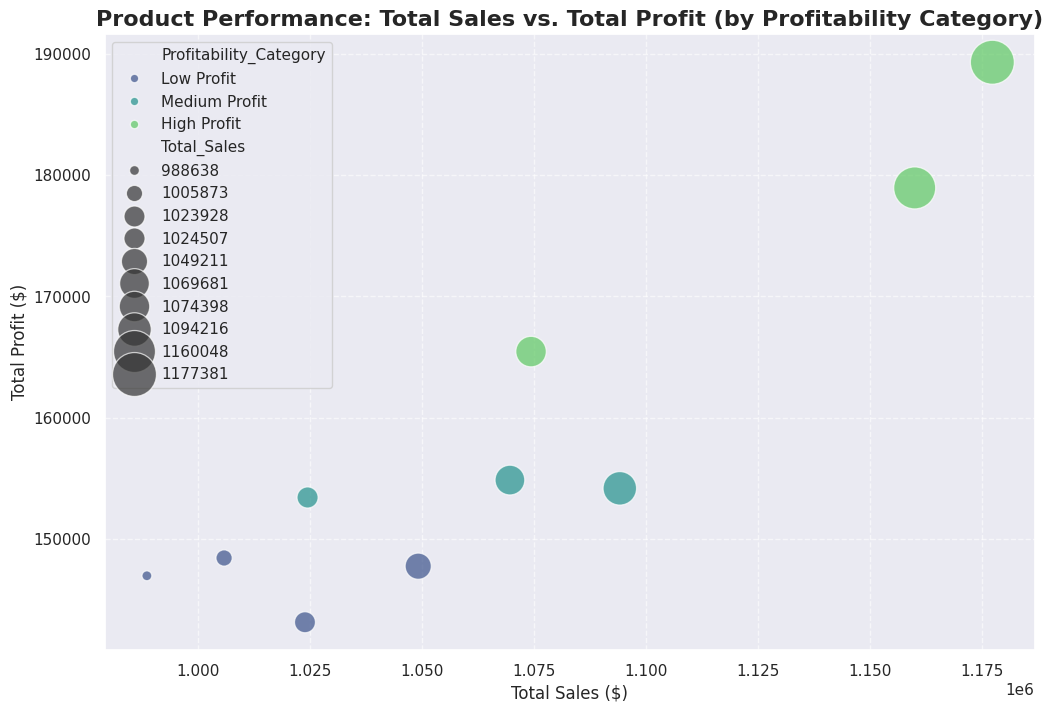

✅ Scatter plot generated for product performance visualization.


In [48]:
print("--- 3. Visualize Product Performance (Scatter Plot) ---")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=product_performance,
    x='Total_Sales',
    y='Total_Profit',
    hue='Profitability_Category', # Color-code by profitability category
    size='Total_Sales', # Make marker size proportional to sales volume for additional insight
    sizes=(50, 1000), # Define range of sizes
    palette='viridis', # Use a distinct color palette
    alpha=0.7,
    legend='full'
)

plt.title('Product Performance: Total Sales vs. Total Profit (by Profitability Category)', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("✅ Scatter plot generated for product performance visualization.")

In [49]:
print("--- 4. Generate Summary Table for Combined Categories ---")

# Create a cross-tabulation of Profitability_Category and Sales_Volume_Category
combined_category_summary = pd.crosstab(product_performance['Profitability_Category'], product_performance['Sales_Volume_Category'])

print("✅ Summary table generated for combined product categories:")
print(combined_category_summary)

--- 4. Generate Summary Table for Combined Categories ---
✅ Summary table generated for combined product categories:
Sales_Volume_Category   Low Sales  Medium Sales  High Sales
Profitability_Category                                     
Low Profit                      3             1           0
Medium Profit                   1             1           1
High Profit                     0             1           2


## Customer Segmentation for Targeted Strategies

In [50]:
print("--- 1. Aggregating data by Product Name ---")
customer_segments = df.groupby('Product Name').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

print("✅ Aggregated data by Product Name successfully.")
print(customer_segments.head())

--- 1. Aggregating data by Product Name ---
✅ Aggregated data by Product Name successfully.
  Product Name  Total_Quantity  Total_Sales  Total_Profit
0       Camera            1795      1177381     189340.42
1   Headphones            1604       988638     146938.16
2     Keyboard            1684      1024507     153403.62
3       Laptop            1658      1005873     148407.43
4      Monitor            1876      1160048     178964.10


In [51]:
print("--- 2. Selecting Numerical Features for Clustering ---")
numerical_features = ['Total_Quantity', 'Total_Sales', 'Total_Profit']
X_cluster = customer_segments[numerical_features]

print("✅ Selected numerical features for clustering:")
print(X_cluster.head())


--- 2. Selecting Numerical Features for Clustering ---
✅ Selected numerical features for clustering:
   Total_Quantity  Total_Sales  Total_Profit
0            1795      1177381     189340.42
1            1604       988638     146938.16
2            1684      1024507     153403.62
3            1658      1005873     148407.43
4            1876      1160048     178964.10


In [52]:
from sklearn.preprocessing import StandardScaler

print("--- 3. Standardizing Numerical Features ---")

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the numerical features
X_scaled = scaler.fit_transform(X_cluster)

print("✅ Numerical features standardized successfully.")
print("Scaled data (first 5 rows):\n", X_scaled[:5])

--- 3. Standardizing Numerical Features ---
✅ Numerical features standardized successfully.
Scaled data (first 5 rows):
 [[ 0.83666241  1.8561895   2.16503864]
 [-1.4826775  -1.31167005 -0.78614205]
 [-0.51122623 -0.70964532 -0.33614857]
 [-0.82694789 -1.02239808 -0.68388144]
 [ 1.82025682  1.5652727   1.44285083]]


--- 4. Determining Optimal Number of Clusters using Elbow Method ---


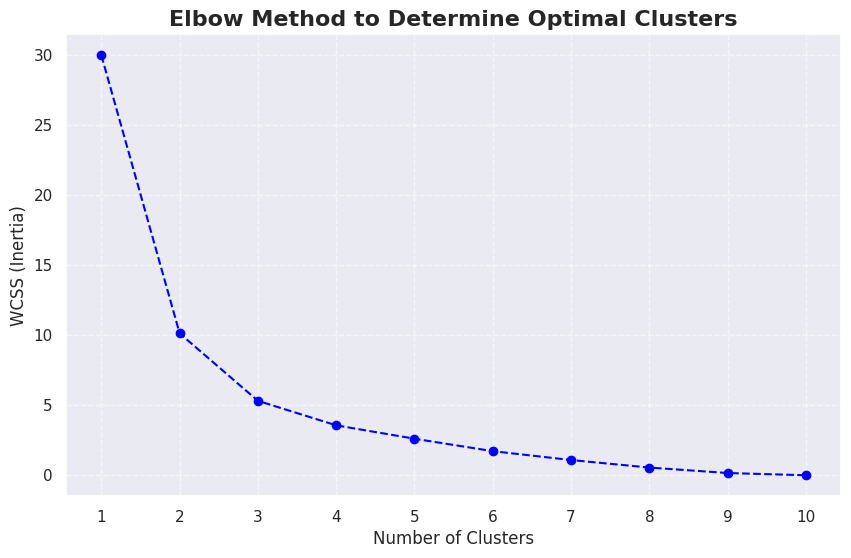

✅ Elbow method plot generated. Analyze the plot to identify the 'elbow point' for the optimal number of clusters.


In [53]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("--- 4. Determining Optimal Number of Clusters using Elbow Method ---")

wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method to Determine Optimal Clusters', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("✅ Elbow method plot generated. Analyze the plot to identify the 'elbow point' for the optimal number of clusters.")

In [54]:
print("--- 5. Applying KMeans Clustering and Assigning Labels ---")

optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

customer_segments['Cluster'] = cluster_labels

print(f"✅ KMeans clustering applied with {optimal_clusters} clusters.")
print("✅ Cluster labels assigned to 'customer_segments' DataFrame.")
print(customer_segments.head())

--- 5. Applying KMeans Clustering and Assigning Labels ---
✅ KMeans clustering applied with 3 clusters.
✅ Cluster labels assigned to 'customer_segments' DataFrame.
  Product Name  Total_Quantity  Total_Sales  Total_Profit  Cluster
0       Camera            1795      1177381     189340.42        1
1   Headphones            1604       988638     146938.16        2
2     Keyboard            1684      1024507     153403.62        2
3       Laptop            1658      1005873     148407.43        2
4      Monitor            1876      1160048     178964.10        1


In [55]:
print("--- 6. Analyzing Characteristics of Each Cluster ---")

cluster_characteristics = customer_segments.groupby('Cluster')[numerical_features].mean()

print("✅ Mean characteristics for each cluster (unscaled features):")
print(cluster_characteristics)


--- 6. Analyzing Characteristics of Each Cluster ---
✅ Mean characteristics for each cluster (unscaled features):
         Total_Quantity  Total_Sales  Total_Profit
Cluster                                           
0               1756.75   1060438.25   152609.9725
1               1835.50   1168714.50   184152.2600
2               1640.75   1022174.75   150897.3175


## Interactive Dashboards and Reporting


In [57]:
import plotly.express as px

print("--- 1. Creating Interactive Monthly Sales Trend Plot ---")
fig1 = px.line(monthly_sales, title='Interactive Monthly Sales Trend', labels={'value':'Total Sales ($)', 'Order Date':'Date'})
fig1.show()
print("✅ Interactive Monthly Sales Trend plot displayed.")

print("\n--- 2. Creating Interactive Average Profit Margin by Category Plot ---")
# Calculating average profit margin per category
profit_margin_by_category = df.groupby('Category')['Profit_Margin_%'].mean().reset_index()
fig2 = px.bar(profit_margin_by_category,
              x='Category',
              y='Profit_Margin_%',
              title='Interactive Average Profit Margin by Category',
              labels={'Profit_Margin_%':'Average Profit Margin (%)'})
fig2.show()
print("✅ Interactive Average Profit Margin by Category plot displayed.")

print("\n--- 3. Creating Interactive Product Performance Plot ---")

if 'product_performance' not in locals() or product_performance.empty:
    product_performance = df.groupby('Product Name').agg(
        Total_Profit=('Profit', 'sum'),
        Total_Sales=('Sales', 'sum')
    ).reset_index()
    product_performance['Profitability_Category'] = pd.qcut(
        product_performance['Total_Profit'],
        q=3,
        labels=['Low Profit', 'Medium Profit', 'High Profit'],
        duplicates='drop'
    )

fig3 = px.scatter(product_performance,
                  x='Total_Sales',
                  y='Total_Profit',
                  color='Profitability_Category',
                  size='Total_Sales',
                  hover_name='Product Name',
                  title='Interactive Product Performance: Sales vs. Profit',
                  labels={'Total_Sales':'Total Sales ($)', 'Total_Profit':'Total Profit ($)'})
fig3.show()
print("✅ Interactive Product Performance plot displayed.")

--- 1. Creating Interactive Monthly Sales Trend Plot ---


✅ Interactive Monthly Sales Trend plot displayed.

--- 2. Creating Interactive Average Profit Margin by Category Plot ---


✅ Interactive Average Profit Margin by Category plot displayed.

--- 3. Creating Interactive Product Performance Plot ---


✅ Interactive Product Performance plot displayed.


# Machine Learning | Loss Prevension


--- 5. MACHINE LEARNING ---
--- 5.1. Defining the Business Problem & Data Preparation ---
✅ Data prepared and text categories mathematically encoded.
Distribution of Is_Profitable in training set: Is_Profitable
1    0.9
0    0.1
Name: proportion, dtype: float64
Distribution of Is_Profitable in test set: Is_Profitable
1    0.9
0    0.1
Name: proportion, dtype: float64

--- 5.2. Training the AI ---
✅ AI Model successfully trained.

--- 5.3. Evaluating the Results (Confusion Matrix) ---
🎯 Model Accuracy: 86.43%



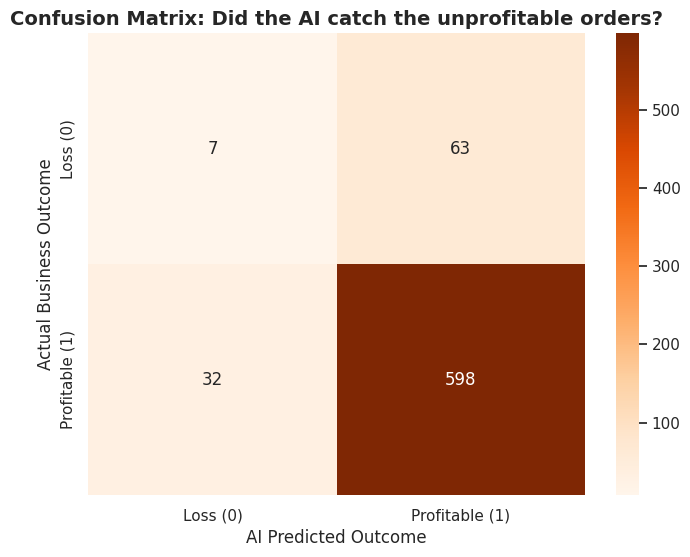


📊 Detailed Diagnostic Report:
                precision    recall  f1-score   support

      Loss (0)       0.18      0.10      0.13        70
Profitable (1)       0.90      0.95      0.93       630

      accuracy                           0.86       700
     macro avg       0.54      0.52      0.53       700
  weighted avg       0.83      0.86      0.85       700


--- 5.4. Feature Importance (The 'Why') ---


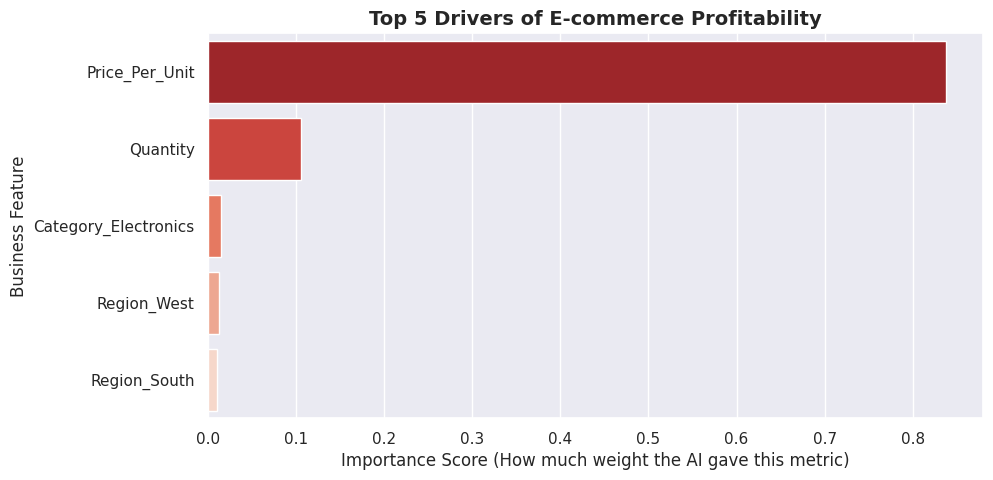

In [58]:
# --- MACHINE LEARNING  ---
print("\n--- 5. MACHINE LEARNING ---")
print("--- 5.1. Defining the Business Problem & Data Preparation ---")
# Target Variable: 1 if Profitable (Profit > 0), 0 if Loss (Profit <= 0)
df['Is_Profitable'] = (df['Profit'] > 0).astype(int)

# Features to predict profitability
features = ['Quantity', 'Category', 'Region', 'Price_Per_Unit']
ml_data = df[features + ['Is_Profitable']].dropna()

X = pd.get_dummies(ml_data[features], drop_first=True)
y = ml_data['Is_Profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Added stratify
print("✅ Data prepared and text categories mathematically encoded.")
print(f"Distribution of Is_Profitable in training set: {y_train.value_counts(normalize=True).round(2)}")
print(f"Distribution of Is_Profitable in test set: {y_test.value_counts(normalize=True).round(2)}")

print("\n--- 5.2. Training the AI ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ AI Model successfully trained.")

print("\n--- 5.3. Evaluating the Results (Confusion Matrix) ---")
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%\n")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Loss (0)', 'Profitable (1)'],
            yticklabels=['Loss (0)', 'Profitable (1)'])
plt.title('Confusion Matrix: Did the AI catch the unprofitable orders?', fontsize=14, fontweight='bold')
plt.xlabel('AI Predicted Outcome', fontsize=12)
plt.ylabel('Actual Business Outcome', fontsize=12)
plt.show()

print("\n📊 Detailed Diagnostic Report:")
# Determine the actual unique classes in y_test
actual_classes = y_test.unique()

# Adjusting target_names dynamically based on actual classes present
if len(actual_classes) == 1:
    if actual_classes[0] == 1:
        report_target_names = ['Profitable (1)']
    else:
        report_target_names = ['Loss (0)']
    print(classification_report(y_test, y_pred, labels=actual_classes, target_names=report_target_names))
else:
    print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profitable (1)']))

print("\n--- 5.4. Feature Importance (The 'Why') ---")
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='Reds_r')
plt.title('Top 5 Drivers of E-commerce Profitability', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (How much weight the AI gave this metric)', fontsize=12)
plt.ylabel('Business Feature', fontsize=12)
plt.show()

# Thank You